# 策略績效比較與參數分析
此 Notebook 專門用來讀取 `results` 內的各策略數據，並產出圖表做進一步的比較。

In [26]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

# 設定圖表樣式與中文字型
# 將字體直接設進 seaborn 的 theme 中
sns.set_theme(style="whitegrid", font="Microsoft JhengHei")

# 增加備用字體清單，避免單一字體找不到時直接崩潰
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Microsoft YaHei', 'Arial', 'sans-serif'] 
plt.rcParams['axes.unicode_minus'] = False


results_dir = r"../results"


## 1. 讀取並清洗資料

In [27]:
summary_files = []
for root, dirs, files in os.walk(results_dir):
    for file in files:
        if file == "grid_search_summary.csv":
            summary_files.append(os.path.join(root, file))

all_data = []
for file in summary_files:
    strategy_name = os.path.basename(os.path.dirname(file))
    df = pd.read_csv(file)
    df['Strategy'] = strategy_name
    
    # 統一報酬率欄位名稱
    if 'Annualized Return (%)' in df.columns:
        df.rename(columns={'Annualized Return (%)': 'CAGR (%)'}, inplace=True)
        
    all_data.append(df)

if all_data:
    df_all = pd.concat(all_data, ignore_index=True)
    print(f"成功載入 {len(summary_files)} 個策略結果，共 {len(df_all)} 筆參數配置。")
else:
    print("未找到任何結果檔案。")


成功載入 13 個策略結果，共 351 筆參數配置。


## 2. 擷取最佳 EG 與最佳 SSD (前 10 名) 進行對比
EG 選擇最高 CAGR；SSD 選擇最高 Sharpe Ratio。

In [28]:
# 尋找各策略最佳績效前 10 名 (依據 CAGR 與 Sharpe)
best_eg_10 = df_all[df_all['Strategy'].str.contains('EG')].sort_values(by='CAGR (%)', ascending=False).head(10)
best_ssd_10 = df_all[df_all['Strategy'].str.contains('SSD')].sort_values(by='Sharpe Ratio', ascending=False).head(10)

compare_df_10 = pd.concat([best_eg_10, best_ssd_10])
print("=== EG 前 10 名最佳配置 (依 CAGR 排序) ===")
display(best_eg_10[['Strategy', 'Top_N_Pairs', 'Stop_Loss', 'CAGR (%)', 'Sharpe Ratio', 'Max Drawdown (%)', 'Period Win Rate (%)']])

print("\n=== SSD 前 10 名最佳配置 (依 Sharpe Ratio 排序) ===")
display(best_ssd_10[['Strategy', 'Top_N_Pairs', 'Stop_Loss', 'CAGR (%)', 'Sharpe Ratio', 'Max Drawdown (%)', 'Period Win Rate (%)']])


=== EG 前 10 名最佳配置 (依 CAGR 排序) ===


,Strategy,Top_N_Pairs,Stop_Loss,CAGR (%),Sharpe Ratio,Max Drawdown (%),Period Win Rate (%)
136,EG_ReEntry_Sector,3,15%,-0.29,-1.34,-23.02,52.7
139,EG_ReEntry_Sector,5,15%,-0.31,-1.54,-21.62,52.0
145,EG_ReEntry_Sector,5,5%,-0.36,-2.09,-18.86,46.3
118,EG_NoReEntry_Sector,5,5%,-0.45,-2.30,-20.07,44.6
143,EG_ReEntry_Sector,3,5%,-0.57,-1.91,-22.55,43.2
112,EG_NoReEntry_Sector,5,15%,-0.58,-1.52,-27.17,52.4
147,EG_ReEntry_Sector,20,15%,-0.64,-2.41,-19.85,39.1
120,EG_NoReEntry_Sector,20,15%,-0.68,-2.44,-20.75,40.1
109,EG_NoReEntry_Sector,3,15%,-0.68,-1.31,-28.63,50.7
132,EG_NoReEntry_Sector,20,0%,-0.77,-13.33,-18.08,13.9



=== SSD 前 10 名最佳配置 (依 Sharpe Ratio 排序) ===


,Strategy,Top_N_Pairs,Stop_Loss,CAGR (%),Sharpe Ratio,Max Drawdown (%),Period Win Rate (%)
216,SSDc_ReEntry_Sector,20,0% (No SL),0.48,0.20,-9.61,52.7
217,SSDc_ReEntry_Sector,5,15%,0.52,0.18,-8.95,51.4
189,SSDc_NoReEntry_Sector,20,0% (No SL),0.41,0.17,-10.47,50.7
162,SSDc_NoReEntry_NoSector,20,15%,0.34,0.16,-11.16,49.3
218,SSDc_ReEntry_Sector,5,0% (No SL),0.58,0.16,-12.54,52.4
219,SSDc_ReEntry_Sector,20,15%,0.26,0.14,-9.16,50.7
190,SSDc_NoReEntry_Sector,5,0% (No SL),0.49,0.14,-12.40,50.7
220,SSDc_ReEntry_Sector,3,15%,0.40,0.11,-13.68,50.3
163,SSDc_NoReEntry_NoSector,3,15%,0.41,0.10,-15.85,50.7
191,SSDc_NoReEntry_Sector,5,15%,0.26,0.09,-8.89,48.6


## 3. 最佳策略淨值圖直觀對比

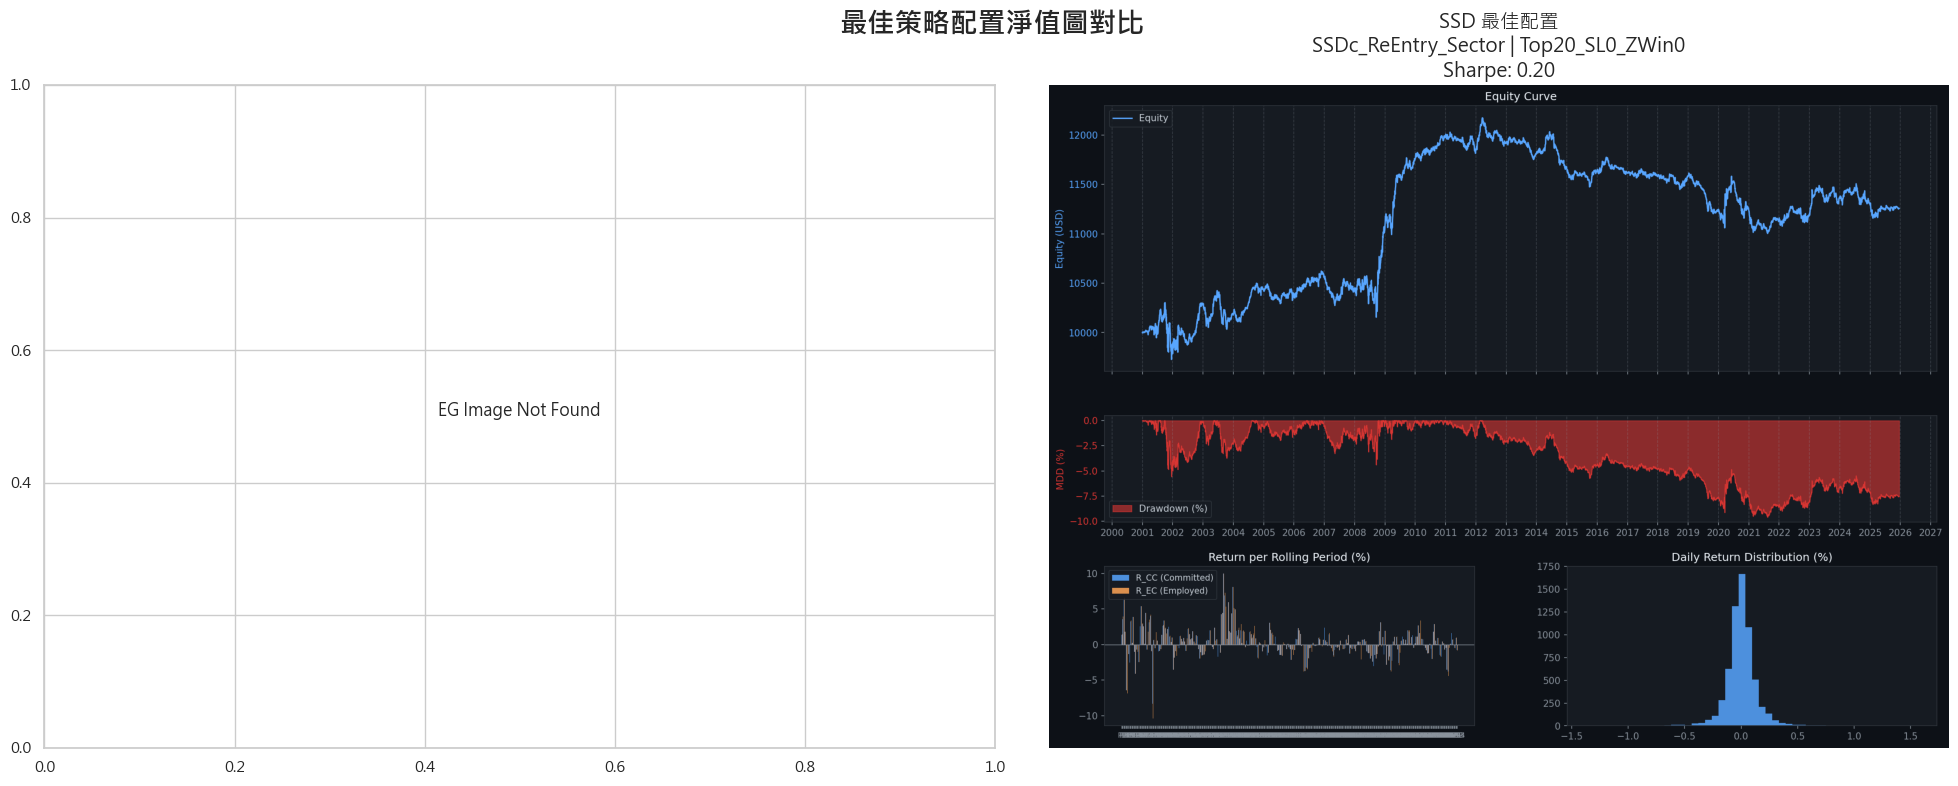

In [29]:
def get_image_path(row):
    strategy = row['Strategy']
    top_n = row['Top_N_Pairs']
    sl = str(row['Stop_Loss']).replace('%', '').replace(' (No SL)', '')
    zw = int(row['Z_Window'])
    
    if 'EG' in strategy:
        ez = int(row['Entry_Z'] * 10)
        folder_name = f"Top{top_n}_SL{sl}_EZ{ez}_ZW{zw}"
    else:
        folder_name = f"Top{top_n}_SL{sl}_ZWin{zw}"
        
    img_path = os.path.join(results_dir, strategy, folder_name, 'performance_chart.png')
    return img_path

best_eg_top1 = best_eg_10.iloc[0]
best_ssd_top1 = best_ssd_10.iloc[0]

eg_img_path = get_image_path(best_eg_top1)
ssd_img_path = get_image_path(best_ssd_top1)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('最佳策略配置淨值圖對比', fontsize=20, fontweight='bold')

if os.path.exists(eg_img_path):
    img = mpimg.imread(eg_img_path)
    axes[0].imshow(img)
    axes[0].axis('off')
    axes[0].set_title(f"EG 最佳配置\n{best_eg_top1['Strategy']} | {os.path.basename(os.path.dirname(eg_img_path))}\nCAGR: {best_eg_top1['CAGR (%)']:.2f}%", fontsize=14)
else:
    axes[0].text(0.5, 0.5, 'EG Image Not Found', ha='center')
    
if os.path.exists(ssd_img_path):
    img = mpimg.imread(ssd_img_path)
    axes[1].imshow(img)
    axes[1].axis('off')
    axes[1].set_title(f"SSD 最佳配置\n{best_ssd_top1['Strategy']} | {os.path.basename(os.path.dirname(ssd_img_path))}\nSharpe: {best_ssd_top1['Sharpe Ratio']:.2f}", fontsize=14)
else:
    axes[1].text(0.5, 0.5, 'SSD Image Not Found', ha='center')

plt.tight_layout()
plt.show()


## 4. 全局參數分佈比較
了解各個策略整體參數測試下來的風險與報酬分佈情況。

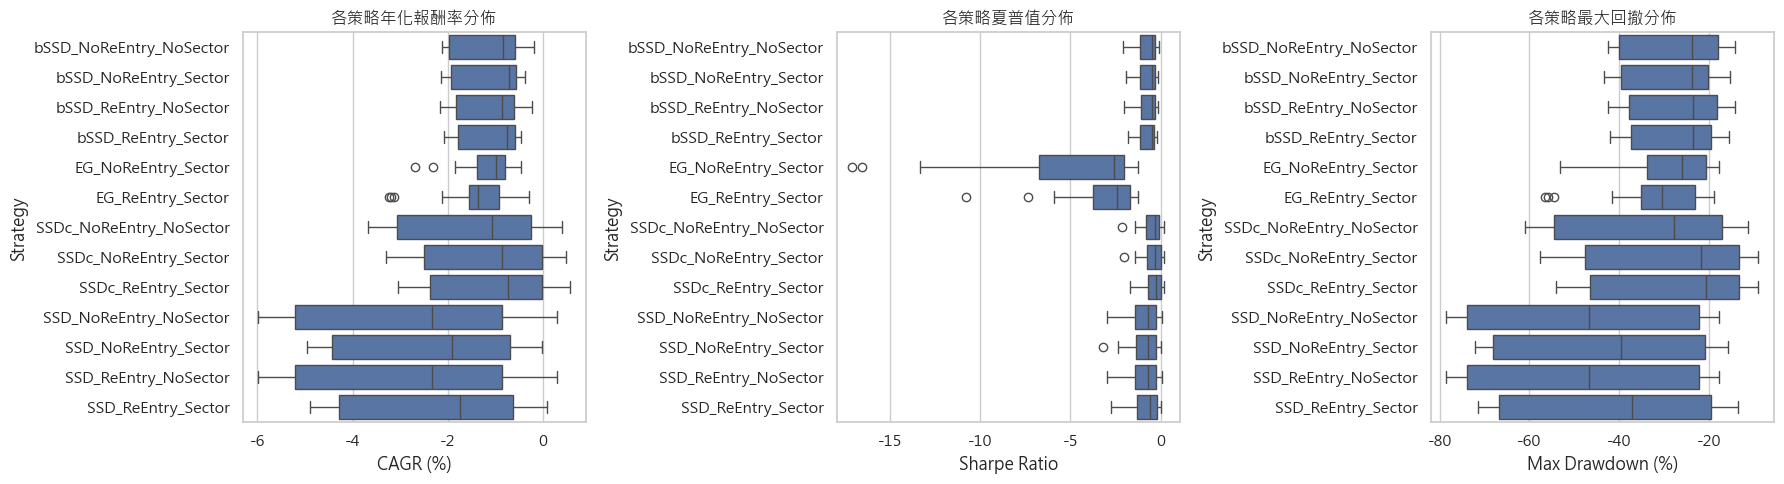

In [30]:
# 綜觀所有策略的分佈
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df_all, x='CAGR (%)', y='Strategy', ax=axes[0])
axes[0].set_title('各策略年化報酬率分佈')

sns.boxplot(data=df_all, x='Sharpe Ratio', y='Strategy', ax=axes[1])
axes[1].set_title('各策略夏普值分佈')

sns.boxplot(data=df_all, x='Max Drawdown (%)', y='Strategy', ax=axes[2])
axes[2].set_title('各策略最大回撤分佈')

plt.tight_layout()
plt.show()
